<a href="https://colab.research.google.com/github/matthewhawksby/colabnotebooks/blob/main/CMPT_419_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
#Imports

from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchaudio
import pandas as pd
from transformers import Wav2Vec2Processor, Wav2Vec2Model, get_linear_schedule_with_warmup
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
import argparse
import torch.nn.functional as F

#AdamW was moved from transformers ## LINE CHANGED ##
#from transformers import Wav2Vec2Processor, Wav2Vec2Model, AdamW, get_linear_schedule_with_warmup
from torch.optim import AdamW
import numpy as np


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
#Define Dataloader
class StressDataset(Dataset):
    def __init__(self, audio_dir, annotation_dir, processor, target_sampling_rate=16000, max_duration=200):
        self.audio_dir = audio_dir
        self.annotation_dir = annotation_dir
        self.processor = processor
        self.target_sampling_rate = target_sampling_rate
        self.max_duration = max_duration

        all_ann_files = sorted([f for f in os.listdir(annotation_dir) if f.endswith('.csv')])

        # Filter out annotations whose corresponding audio file does not exist
        self.annotation_files = []
        for ann_file in all_ann_files:
            parts = ann_file.split('_')
            if len(parts) < 2:
                continue
            base_id = parts[1]
            prefix = parts[0]
            audio_filename = f"{prefix}_{base_id}_AUDIO_PPT.wav"
            audio_path = os.path.join(audio_dir, audio_filename)
            if os.path.exists(audio_path):
                self.annotation_files.append(ann_file)
            else:
                print(f"Warning: Missing audio file for {ann_file} (expected {audio_filename}). Skipping sample.")

    def __len__(self):
        return len(self.annotation_files)

    def __getitem__(self, idx):
        ann_path = os.path.join(self.annotation_dir, self.annotation_files[idx])
        df = pd.read_csv(ann_path, sep=',')
        labels = torch.tensor(df['Fused'].values, dtype=torch.float)
        if len(labels) > self.max_duration:
            labels = labels[:self.max_duration]

        parts = self.annotation_files[idx].split('_')
        base_id = parts[1]
        prefix = parts[0]
        audio_filename = f"{prefix}_{base_id}_AUDIO_PPT.wav"
        audio_path = os.path.join(self.audio_dir, audio_filename)

        waveform, sr = torchaudio.load(audio_path)
        waveform = waveform.mean(dim=0, keepdim=True)  # convert to mono
        if sr != self.target_sampling_rate:
            resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=self.target_sampling_rate)
            waveform = resampler(waveform)

        target_length = self.target_sampling_rate * len(labels)
        if waveform.shape[1] > target_length:
            waveform = waveform[:, :target_length]
        elif waveform.shape[1] < target_length:
            pad_amt = target_length - waveform.shape[1]
            waveform = F.pad(waveform, (0, pad_amt))

        sample = {"waveform": waveform.squeeze(0), "labels": labels}
        return sample


In [11]:

# fn for normalizing and padding input files for model
def create_collate_fn(processor):
    def collate_fn(batch):
        waveforms = [sample["waveform"].cpu().numpy() for sample in batch]
        label_tensors = [sample["labels"] for sample in batch]
        padded_labels = pad_sequence(label_tensors, batch_first=True, padding_value=0.0)

        processor_inputs = processor(
            waveforms,
            sampling_rate=processor.feature_extractor.sampling_rate,
            return_tensors="pt",
            padding=True
        )
        return {"input_values": processor_inputs.input_values, "labels": padded_labels}
    return collate_fn

class Wav2Vec2RegressionModel(nn.Module):
    def __init__(self, model_name="facebook/wav2vec2-base", dropout_p=None):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(model_name)
        self.hidden_size = self.wav2vec2.config.hidden_size
        # Add dropout + linear for regression
        self.use_dropout = dropout_p is not None and dropout_p > 0.0
        self.dropout = nn.Dropout(dropout_p) if self.use_dropout else nn.Identity()

        # NOTE !! You will need to change this based on the model you are using.

        # # 1 Layer of size 128
        # self.regressor = nn.Sequential(
        #     nn.Linear(self.hidden_size, 128),
        #     nn.ReLU(),
        #     nn.Linear(128, 1))

        # 2 layers, 256 -> 128
        self.regressor = nn.Sequential(
            nn.Linear(self.hidden_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

        # 2 layers, 256 -> 256
        # self.regressor = nn.Sequential(
        #     nn.Linear(self.hidden_size, 256),
        #     nn.ReLU(),
        #     nn.Linear(256, 256),
        #     nn.ReLU(),
        #     nn.Linear(256, 1)
        # )

    def forward(self, input_values, target_lengths):
        outputs = self.wav2vec2(input_values=input_values)
        # outputs.last_hidden_state: (batch, T_out, hidden_size)
        hidden_states = outputs.last_hidden_state.transpose(1, 2)  # (batch, hidden_size, T_out)
        batch_size = hidden_states.size(0)
        pooled_outputs = []
        for i in range(batch_size):
            t_len = target_lengths[i]
            # adaptive_avg_pool1d -> (1, hidden_size, t_len)
            pooled = F.adaptive_avg_pool1d(hidden_states[i].unsqueeze(0), output_size=t_len)
            # (1, hidden_size, t_len) -> (t_len, hidden_size)
            pooled = pooled.squeeze(0).transpose(0, 1)
            pooled_outputs.append(pooled)
        # (batch, t_len, hidden_size)
        pooled_outputs = torch.stack(pooled_outputs, dim=0)

        # Apply dropout before regression (if applicable)
        pooled_outputs = self.dropout(pooled_outputs)
        preds = self.regressor(pooled_outputs).squeeze(-1)  # (batch, t_len)
        # sigmoid function was causing restrictions to the prediction range, commented out for now
        # preds = torch.sigmoid(preds)
        return preds

# Training, eval and inference functions

def evaluate(model, dataloader, device, criterion, bin_weights, bin_edges):
    model.eval()
    total_loss = 0.0
    n_samples = 0
    with torch.no_grad():
        for batch in dataloader:
            input_values = batch["input_values"].to(device)
            labels = batch["labels"].to(device)
            target_lengths = [labels.shape[1]] * input_values.shape[0]
            preds = model(input_values, target_lengths)
            if criterion.__name__ == "inverse_weighted_ccc_loss":
                loss = criterion(preds, labels, bin_weights, bin_edges)
            else:
                loss = criterion(preds, labels)
            total_loss += loss.item() * input_values.shape[0]
            n_samples += input_values.shape[0]
    return total_loss / n_samples if n_samples > 0 else 0.0

def load_datasets(base_dir, train_folders, test_folders, processor, max_duration):
    train_datasets = []
    for folder in train_folders:
        audio_dir = os.path.join(base_dir, folder, "Audio")
        annotation_dir = os.path.join(base_dir, folder, "Annotation")
        ds = StressDataset(audio_dir=audio_dir, annotation_dir=annotation_dir, processor=processor, max_duration=max_duration)
        train_datasets.append(ds)
    train_dataset = ConcatDataset(train_datasets)

    test_datasets = []
    for folder in test_folders:
        audio_dir = os.path.join(base_dir, folder, "Audio")
        annotation_dir = os.path.join(base_dir, folder, "Annotation")
        ds = StressDataset(audio_dir=audio_dir, annotation_dir=annotation_dir, processor=processor, max_duration=max_duration)
        test_datasets.append(ds)
    test_dataset = ConcatDataset(test_datasets)

    return train_dataset, test_dataset

def ccc_loss(preds, labels, eps=1e-8):
    """
    Compute the Concordance Correlation Coefficient (CCC) loss.

    The CCC is defined as:
      CCC = 2 * covariance(x, y) / (var(x) + var(y) + (mean(x) - mean(y))**2)

    We use (1 - CCC) as the loss to be minimized.
    """
    x = preds.view(-1)
    y = labels.view(-1)
    x_mean = x.mean()
    y_mean = y.mean()
    covariance = ((x - x_mean) * (y - y_mean)).sum() / (x.numel() - 1 + eps)
    x_var = x.var(unbiased=True) + eps
    y_var = y.var(unbiased=True) + eps
    ccc = (2 * covariance) / (x_var + y_var + (x_mean - y_mean) ** 2)
    return 1 - ccc

# Weighted
def weighted_ccc_loss(preds, labels, low_thresh=0.2, high_thresh=0.5, high_weight=2.0, eps=1e-8):
    """
    Computes a weighted Concordance Correlation Coefficient (CCC) loss.

    This version upweights samples where the target label is:
    - less than `low_thresh`, or
    - greater than `high_thresh`.

    Args:
        preds (Tensor): Predicted values, shape (batch, time)
        labels (Tensor): Ground truth values, shape (batch, time)
        low_thresh (float): Lower bound for emphasizing low-stress values.
        high_thresh (float): Upper bound for emphasizing high-stress values.
        high_weight (float): Weight multiplier for rare (low/high) labels.
        eps (float): Small constant to prevent division by zero.

    Returns:
        Tensor: Weighted CCC loss (scalar).
    """
    x = preds.view(-1)
    y = labels.view(-1)

    weights = torch.ones_like(y)
    weights[y < low_thresh] = high_weight
    weights[y > high_thresh] = high_weight

    # Compute weighted means
    w = weights
    x_mean = (w * x).sum() / (w.sum() + eps)
    y_mean = (w * y).sum() / (w.sum() + eps)

    # Compute weighted covariance and variances
    cov = (w * (x - x_mean) * (y - y_mean)).sum() / (w.sum() + eps)
    x_var = (w * (x - x_mean).pow(2)).sum() / (w.sum() + eps)
    y_var = (w * (y - y_mean).pow(2)).sum() / (w.sum() + eps)

    # CCC formula
    ccc = (2 * cov) / (x_var + y_var + (x_mean - y_mean).pow(2) + eps)
    return 1 - ccc

import torch

def inverse_weighted_ccc_loss(preds, labels, bin_weights, bin_edges, eps=1e-8):
    """
    Computes a weighted Concordance Correlation Coefficient (CCC) loss.

    This version uses inverse frequency weighting to upweight rare labels.

    Args:
        preds (Tensor): Predicted values, shape (batch, time)
        labels (Tensor): Ground truth values, shape (batch, time)

    preds, labels: tensors of shape [batch, time]
    bin_weights: numpy array of shape [num_bins]
    bin_edges: numpy array of shape [num_bins + 1]
    """
    x = preds.view(-1)
    y = labels.view(-1)

    bin_indices = np.digitize(y.cpu().numpy(), bin_edges[:-1], right=True)
    bin_indices = np.clip(bin_indices, 0, len(bin_weights) - 1)
    weights_np = np.array([bin_weights[i] for i in bin_indices])
    weights = torch.tensor(weights_np, dtype=torch.float32, device=preds.device)

    w = weights
    x_mean = (w * x).sum() / (w.sum() + eps)
    y_mean = (w * y).sum() / (w.sum() + eps)

    cov = (w * (x - x_mean) * (y - y_mean)).sum() / (w.sum() + eps)
    x_var = (w * (x - x_mean).pow(2)).sum() / (w.sum() + eps)
    y_var = (w * (y - y_mean).pow(2)).sum() / (w.sum() + eps)

    ccc = (2 * cov) / (x_var + y_var + (x_mean - y_mean).pow(2) + eps)
    return 1 - ccc


def combined_ccc_L1_loss(preds, labels, alpha=0.5):
    # Compute the Concordance Correlation Coefficient (CCC) loss
    # calculates how well a predicted sequence matches the shape and mean of the target sequence.
    loss_ccc = ccc_loss(preds, labels)

    # this measures how close each pred is to true value (each time step)
    loss_smoothl1 = nn.SmoothL1Loss()(preds, labels)

    # Combine the two losses with a weighted average
    # alpha controls how much weight is given to CCC vs. SmoothL1
    # alpha=0.5 means equal importance to both losses
    return alpha * loss_ccc + (1 - alpha) * loss_smoothl1

def get_loss_function(name):
    name = name.lower().replace("_", "").replace("-", "")
    if name == "cccloss":
        return ccc_loss
    elif name == "mseloss":
        return nn.MSELoss()
    elif name == "l1smoothloss":
        return nn.SmoothL1Loss()
    elif name == "combinedcccloss":
        return combined_ccc_L1_loss
    elif name == "weightedcccloss":
        return weighted_ccc_loss
    elif name == "inverseweightedcccloss":
        return inverse_weighted_ccc_loss
    else:
        raise ValueError(f"Unknown loss function: {name}")

# regular train model function without freezing any layers
def train_model(model,
                train_dataloader,
                test_dataloader,
                device,
                bin_weights,
                bin_edges,
                processor_for_plot,
                encoder_lr,
                regressor_lr,
                weight_decay,
                loss_fn,
                name,
                n_epochs=3,
                plot_dir="plots",
                plot_annotation_path="VerBIO_v2/VerBIO_v2/PRE/Annotation/PRE_P001_annotation.csv",
                plot_audio_path="VerBIO_v2/VerBIO_v2/PRE/Audio/PRE_P001_AUDIO_PPT.wav",
                ):

    optimizer = AdamW([
        {"params": model.regressor.parameters(), "lr": regressor_lr},
        {"params": [p for n,p in model.wav2vec2.named_parameters() if p.requires_grad], "lr": encoder_lr}
    ], weight_decay=weight_decay)

    total_steps = n_epochs * len(train_dataloader)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )
    criterion = loss_fn
    model.train()
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1} Training"):
            input_values = batch["input_values"].to(device)
            labels = batch["labels"].to(device)
            target_lengths = [labels.shape[1]] * input_values.shape[0]

            optimizer.zero_grad()
            preds = model(input_values, target_lengths)
            ### Added ###
            if loss_fn.__name__ == "inverse_weighted_ccc_loss":
                loss = criterion(preds, labels, bin_weights, bin_edges)
            else:
                loss = criterion(preds, labels)
            ### Added ###
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            torch.cuda.empty_cache()
            epoch_loss += loss.item()
        avg_train_loss = epoch_loss / len(train_dataloader)
        val_loss = evaluate(model, test_dataloader, device, criterion, bin_weights, bin_edges)
        print(f"Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f}, Validation Loss: {val_loss:.4f}")
        if plot_annotation_path and plot_audio_path and processor_for_plot:
            plot_epoch_predictions(name, model, processor_for_plot, device, plot_annotation_path, plot_audio_path, epoch, plot_dir)
    return model

In [12]:

def train_gradual_unfreeze(
    model,
    train_dataloader,
    test_dataloader,
    device,
    processor_for_plot,
    phases,
    loss_fn,
    name,
    encoder_lr,
    regressor_lr,
    weight_decay=1e-6,
    bin_weights=None,
    bin_edges=None,
    plot_annotation_path="VerBIO_v2/VerBIO_v2/PRE/Annotation/PRE_P001_annotation.csv",
    plot_audio_path="VerBIO_v2/VerBIO_v2/PRE/Audio/PRE_P001_AUDIO_PPT.wav",
    plot_dir="plots"
):
    criterion = loss_fn
    total_epochs = sum([p[0] for p in phases])
    total_steps = total_epochs * len(train_dataloader)
    optimizer = AdamW([
        {"params": model.regressor.parameters(), "lr": regressor_lr},
        {"params": [p for n,p in model.wav2vec2.named_parameters() if p.requires_grad], "lr": encoder_lr}
    ], weight_decay=weight_decay)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )
    current_epoch = 0
    os.makedirs(plot_dir, exist_ok=True)

    for (phase_epochs, unfreeze_layers) in phases:
        print(f"Starting phase: {phase_epochs} epochs, unfreeze_layers={unfreeze_layers}")
        # Freeze all layers then unfreeze only the last `unfreeze_layers` blocks.
        for param in model.wav2vec2.parameters():
            param.requires_grad = False
        total_layers = model.wav2vec2.config.num_hidden_layers
        start_layer = max(0, total_layers - unfreeze_layers)
        for name, param in model.wav2vec2.named_parameters():
            for layer_i in range(start_layer, total_layers):
                if f"encoder.layer.{layer_i}." in name:
                    param.requires_grad = True
                    break

        model.train()
        for epoch in range(phase_epochs):
            epoch_loss = 0.0
            for batch in tqdm(train_dataloader, desc=f"Epoch {current_epoch+1} Training"):
                input_values = batch["input_values"].to(device)
                labels = batch["labels"].to(device)
                target_lengths = [labels.shape[1]] * input_values.shape[0]

                optimizer.zero_grad()
                preds = model(input_values, target_lengths)
                loss = criterion(preds, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                epoch_loss += loss.item()
            avg_train_loss = epoch_loss / len(train_dataloader)
            ###Added
            val_loss = evaluate(model, test_dataloader, device, criterion, bin_weights, bin_edges)
            ###Added
            print(f"Epoch {current_epoch+1} - Train Loss: {avg_train_loss:.4f}, Validation Loss: {val_loss:.4f}")

            # Save a plot for this epoch using one sample from the test set.
            if plot_annotation_path and plot_audio_path and processor_for_plot:
                plot_epoch_predictions(name, model, processor_for_plot, device, plot_annotation_path, plot_audio_path, current_epoch, plot_dir)
            current_epoch += 1
    return model


def save_model(model, processor, save_path):
    os.makedirs(save_path, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(save_path, "pytorch_model.bin"))
    processor.save_pretrained(save_path)
    print(f"Model and processor saved to {save_path}")

def load_model(save_path, device):
    model = Wav2Vec2RegressionModel()
    model.load_state_dict(torch.load(os.path.join(save_path, "pytorch_model.bin"), map_location=device))
    model.to(device)
    model.eval()
    processor = Wav2Vec2Processor.from_pretrained(save_path)
    return model, processor

def infer_on_audio(model, audio_path, processor, device):
    model.eval()
    waveform, sr = torchaudio.load(audio_path)
    waveform = waveform.mean(dim=0, keepdim=True)
    if sr != processor.feature_extractor.sampling_rate:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=processor.feature_extractor.sampling_rate)
        waveform = resampler(waveform)
    n_seconds = waveform.shape[1] // processor.feature_extractor.sampling_rate
    total_samples = n_seconds * processor.feature_extractor.sampling_rate
    if waveform.shape[1] > total_samples:
        waveform = waveform[:, :total_samples]
    elif waveform.shape[1] < total_samples:
        pad_amt = total_samples - waveform.shape[1]
        waveform = F.pad(waveform, (0, pad_amt))
    input_values = processor(waveform.squeeze(0), sampling_rate=processor.feature_extractor.sampling_rate, return_tensors="pt").input_values.to(device)
    with torch.no_grad():
        preds = model(input_values, [n_seconds])
    return preds.cpu().numpy()

def real_time_inference(model, audio_path, processor, device, chunk_duration=1.0):
    import time

    model.eval()
    waveform, sr = torchaudio.load(audio_path)
    waveform = waveform.mean(dim=0, keepdim=True)

    if sr != processor.feature_extractor.sampling_rate:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=processor.feature_extractor.sampling_rate)
        waveform = resampler(waveform)

    sr = processor.feature_extractor.sampling_rate
    chunk_size = int(sr * chunk_duration)
    total_samples = waveform.shape[1]

    print(f"Starting real-time inference on '{audio_path}' ({total_samples/sr:.2f} seconds)")
    predictions = []
    total_start_time = time.time()

    for start in range(0, total_samples, chunk_size):
        end = start + chunk_size
        chunk = waveform[:, start:end]

        if chunk.shape[1] < chunk_size:
            pad_amt = chunk_size - chunk.shape[1]
            chunk = F.pad(chunk, (0, pad_amt))

        input_values = processor(chunk.squeeze(0), sampling_rate=sr, return_tensors="pt").input_values.to(device)

        # Time the inference for this chunk
        start_time = time.time()
        with torch.no_grad():
            pred = model(input_values, [1])[0][0].item()
        end_time = time.time()

        inference_time = end_time - start_time
        predictions.append(pred)

        current_time = start / sr
        print(f"Time {current_time:>5.1f}s: Predicted Stress = {pred:.3f} | Inference Time = {inference_time:.4f}s")

    total_inference_time = time.time() - total_start_time
    print(f"\nTotal Real-Time Inference Time: {total_inference_time:.3f} seconds")

    return predictions


In [13]:

def plot_continuous_testset(model, processor, device, audio_dir, annotation_dir, output_path="test08_full_plot.png"):
    model.eval()
    all_preds = []
    all_gts = []

    audio_files = sorted([f for f in os.listdir(audio_dir) if f.endswith(".wav")])

    for audio_file in audio_files:
        base_name = audio_file.replace("_AUDIO_PPT.wav", "")
        ann_file = f"{base_name}_annotation.csv"
        ann_path = os.path.join(annotation_dir, ann_file)

        if not os.path.exists(ann_path):
            print(f"Annotation missing for {audio_file}, skipping...")
            continue

        # Load and preprocess waveform
        audio_path = os.path.join(audio_dir, audio_file)
        waveform, sr = torchaudio.load(audio_path)
        waveform = waveform.mean(dim=0, keepdim=True)
        if sr != processor.feature_extractor.sampling_rate:
            resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=processor.feature_extractor.sampling_rate)
            waveform = resampler(waveform)

        sr = processor.feature_extractor.sampling_rate
        n_seconds = waveform.shape[1] // sr
        waveform = waveform[:, :n_seconds * sr]  # Trim or pad
        input_values = processor(waveform.squeeze(0), sampling_rate=sr, return_tensors="pt", padding=True).input_values.to(device)

        with torch.no_grad():
            preds = model(input_values, [n_seconds])[0].cpu().numpy()

        df = pd.read_csv(ann_path)
        gts = df['Fused'].values
        if len(gts) > n_seconds:
            gts = gts[:n_seconds]
        elif len(gts) < n_seconds:
            preds = preds[:len(gts)]  # trim prediction to match if needed

        all_preds.extend(preds)
        all_gts.extend(gts)

    # Plot
    plt.figure(figsize=(14, 6))
    plt.plot(all_gts, label="Ground Truth", color="blue", linewidth=1)
    plt.plot(all_preds, label="Predicted", color="red", linestyle="--", linewidth=1)
    plt.xlabel("Time (seconds across all samples)")
    plt.ylabel("Stress Value")
    plt.title("Continuous Ground Truth vs. Predictions - TEST08")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path)
    plt.close()
    print(f"Saved full test08 plot to {output_path}")

def plot_predictions(annotation_path, prediction):
    print("Plotting Predictions to inference_plot.png")

    df = pd.read_csv(annotation_path, sep=',')
    gt_values = df['Fused'].values
    predicted_values = prediction[0]

    # Match length to avoid dimension mismatch
    min_len = min(len(gt_values), len(predicted_values))
    gt_values = gt_values[:min_len]
    predicted_values = predicted_values[:min_len]

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(gt_values, label="Ground Truth", color="blue", marker="o")
    plt.plot(predicted_values, label="Predictions", color="red", linestyle="--", marker="x")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Stress Value (0 to 1)")
    plt.title("Ground Truth vs. Predictions (Full Audio)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    # plot_predictions is only for testing/visualization for now, feel free to save this elsewhere/change parameters
    plt.savefig("inference_plot.png")
    plt.close()
    print("Saved full prediction plot to inference_plot.png")

def plot_epoch_predictions(name, model, processor, device, annotation_path, audio_path, epoch, plot_dir="plots"):
    """
    Runs inference on a single test sample and saves a plot of ground truth vs. predictions.

    Args:
      model: The trained model.
      processor: The Wav2Vec2Processor.
      device: The torch device (cpu or cuda).
      annotation_path: Path to the CSV file containing ground truth annotations.
      audio_path: Path to the corresponding audio file.
      epoch: Current epoch number (zero-indexed).
      max_duration: Maximum number of seconds to use from the sample.
      plot_dir: Directory to save plots.
    """


    # Load ground truth annotations.
    df = pd.read_csv(annotation_path, sep=',')
    gt_values = df['Fused'].values

    # Run inference on the audio sample.
    predicted_values = infer_on_audio(model, audio_path, processor, device)
    predicted_values = predicted_values[0]
    min_len = min(len(gt_values), len(predicted_values))
    gt_values = gt_values[:min_len]
    predicted_values = predicted_values[:min_len]

    # Create the plot.
    plt.figure(figsize=(12, 6))
    plt.plot(gt_values, label="Ground Truth", color="blue", marker="o")
    plt.plot(predicted_values, label="Predictions", color="red", linestyle="--", marker="x")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Stress Value (0 to 1)")
    plt.title(f"Epoch {epoch+1} - Ground Truth vs. Predictions")
    plt.legend()

    # Save the plot.
    os.makedirs(plot_dir, exist_ok=True)
    output_file = os.path.join(plot_dir, f"{name}_inference_epoch_{epoch+1}.png")
    plt.savefig(output_file)
    plt.close()
    print(f"Plot for epoch {epoch+1} saved to {output_file}")

def parse_unfreeze_phases(phase_str):
    phases = []
    for p in phase_str.split(","):
        epochs, layers = map(int, p.split("-"))
        phases.append((epochs, layers))
    return phases

def compute_inverse_frequency_weights(all_labels, num_bins=10):
    """
    all_labels: a flat list or 1D np.array of all stress labels in training data
    Returns:
        weights: np.array of shape [num_bins]
        bin_edges: np.array of bin thresholds
    """
    hist, bin_edges = np.histogram(all_labels, bins=num_bins)
    freq = hist / np.sum(hist)
    weights = 1.0 / (freq + 1e-6)
    weights = weights / np.sum(weights)
    return weights, bin_edges



In [14]:

# LINE COMMENTED FOR COLAB
def main(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize the processor
    processor = Wav2Vec2Processor.from_pretrained(args.processor)

    if args.mode == "train":
        base_dir = args.base_dir  # VerBIO_v2/VerBIO_v2 default, change if your folder structure is different
        train_folders = ["POST", "PRE", "TEST01", "TEST02", "TEST03", "TEST04", "TEST05", "TEST06"]
        test_folders = ["TEST08"]
        max_duration = args.max_duration  # in seconds

        train_dataset, test_dataset = load_datasets(base_dir, train_folders, test_folders, processor, max_duration)

        ### Added ####
        loss_fn = get_loss_function(args.loss_fn)

        # Only compute bin weights for inverse-weighted CCC loss
        bin_weights = None
        bin_edges = None
        if args.loss_fn == "inverseweightedcccloss":
            all_labels = []
            for sample in train_dataset:
                all_labels.extend(sample["labels"].tolist())
            bin_weights, bin_edges = compute_inverse_frequency_weights(all_labels, num_bins=10)
        ### Added ###

        collate_fn = create_collate_fn(processor)
        train_dataloader = DataLoader(train_dataset, batch_size=args.batch_size, collate_fn=collate_fn, num_workers=8)

        # train_dataloader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, collate_fn=collate_fn)
        test_dataloader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, collate_fn=collate_fn)

        model = Wav2Vec2RegressionModel(dropout_p=args.dropout)
        model.to(device)

        if args.freeze == "all":
            for param in model.wav2vec2.parameters():
                param.requires_grad = False
            trained_model = train_model(
                model,
                train_dataloader,
                test_dataloader,
                device,
                bin_weights,
                bin_edges,
                processor_for_plot=processor,
                n_epochs=args.epochs,
                regressor_lr = args.regressor_lr,
                encoder_lr = args.encoder_lr,
                weight_decay=args.weight_decay,
                loss_fn = loss_fn,
                name = args.model_path,
                plot_annotation_path=args.annotation_path,
                plot_audio_path=args.audio_path,
                plot_dir = os.path.join("plots", os.path.basename(args.model_path)))

        elif args.freeze == "" or args.freeze == "None":
                trained_model = train_model(
                model,
                train_dataloader,
                test_dataloader,
                device,
                bin_weights,
                bin_edges,
                processor_for_plot=processor,
                n_epochs=args.epochs,
                regressor_lr = args.regressor_lr,
                encoder_lr = args.encoder_lr,
                weight_decay=args.weight_decay,
                loss_fn = get_loss_function(args.loss_fn),
                name = args.model_path,
                plot_annotation_path=args.annotation_path,
                plot_audio_path=args.audio_path,
                plot_dir = os.path.join("plots", os.path.basename(args.model_path)))
        else:
            phases = parse_unfreeze_phases(args.freeze)

            trained_model = train_gradual_unfreeze(
                model,
                train_dataloader,
                test_dataloader,
                device,
                bin_weights,
                bin_edges,
                processor_for_plot=processor,
                phases=phases,
                regressor_lr = args.regressor_lr,
                encoder_lr = args.encoder_lr,
                weight_decay=args.weight_decay,
                loss_fn = get_loss_function(args.loss_fn),
                name = args.model_path,
                plot_annotation_path=args.annotation_path,
                plot_audio_path=args.audio_path,
                plot_dir = os.path.join("plots", os.path.basename(args.model_path)))
        save_model(trained_model, processor, args.model_path)

    elif args.mode == "infer":
        # For single prediction on single path
        # # Load the model from saved path
        # model, processor_loaded = load_model(args.model_path, device)
        # # Run inference on a single audio file
        # predictions = infer_on_audio(model, args.audio_path, processor_loaded, device)
        # print("Predicted Stress (per second):", predictions)
        # # plot predictions if annotation is provided
        # if args.annotation_path:
        #     plot_predictions(args.annotation_path, predictions)

        model, processor = load_model(args.model_path, device)
        plot_continuous_testset(
            model=model,
            processor=processor,
            device=device,
            audio_dir=os.path.join(args.base_dir, "TEST08", "Audio"),
            annotation_dir=os.path.join(args.base_dir, "TEST08", "Annotation")
        )



    elif args.mode == "realtime":
        # Load the model from saved path
        model, processor_loaded = load_model(args.model_path, device)
        predictions = real_time_inference(model, args.audio_path, processor_loaded, device, chunk_duration=args.chunk_duration)
        print("Real-Time Predictions:", predictions)

    else:
        print("Invalid mode specified. Choose from 'train', 'infer', or 'realtime'.")


In [15]:
if __name__ == "__main__":
    import sys
    if "ipykernel" in sys.modules:
        # Running in Colab
        class Args():
            mode = "train"
            base_dir = "/content/drive/MyDrive/Colab Notebooks/VerBIO_v2"
            max_duration = 240

            batch_size = 2
            epochs = 3
            lr = 5e-5
            variable_lr = False
            encoder_lr = 1e-6
            regressor_lr = 1e-4
            freeze = ""
            dropout = 0.05
            weight_decay = 0.0

            loss_fn = "inverseweightedcccloss"
            model_path = "/content/drive/MyDrive/Colab Notebooks/Final Project CMPT419 - Affective Computing"
            audio_path = "/content/drive/MyDrive/Colab Notebooks/VerBIO_v2/PRE/Audio/PRE_P001_AUDIO_PPT.wav"
            annotation_path = "/content/drive/MyDrive/Colab Notebooks/VerBIO_v2/PRE/Annotation/PRE_P001_annotation.csv"
            chunk_duration = 1.0
            processor = "facebook/wav2vec2-base"
        args = Args()
    else:
      #Running from Command Line
        parser = argparse.ArgumentParser(description="Stress Inference using Wav2Vec2 Regression Model")
        parser.add_argument("--mode", type=str, required=True, choices=["train", "infer", "realtime"],
                            help="Mode: 'train' to train the model, 'infer' to run inference, 'realtime' for simulated real-time inference.")
        parser.add_argument("--base_dir", type=str, default="VerBIO_v2/VerBIO_v2",
                            help="Base directory of the dataset (used in training mode)")

        # 100 is the max for using the large model. 200 is the max for the regular model (at least for 24GB VRAM GPUs)
        parser.add_argument("--max_duration", type=int, default=100, help="Max duration (in seconds) to use per sample")

        parser.add_argument("--batch_size", type=int, default=2, help="Batch size for training and evaluation")
        parser.add_argument("--epochs", type=int, default=3, help="Number of training epochs")
        parser.add_argument("--lr", type=float, default=5e-5, help="Learning rate (make sure variable_lr is false if you want encoder + regressor to have the same lr)")
        parser.add_argument("--variable_lr", type=bool, default=False, help="Default is false, set to true if you want regressor and encoder to have different lr")
        parser.add_argument("--encoder_lr", type=float, default=1e-6, help="Default is 1e-6, enabled when variable_lr is true")
        parser.add_argument("--regressor_lr", type=float, default=1e-4, help="Default is 1e-4, enabled when variable_lr is true")
        # Example: --unfreeze_phases 2-0,3-2,3-6,3-12 means in phase 1, no layers are unfrozen (only regressor updates) for 2 epochs, in phase 2, last 2 encoder layers are unfrozen for 3 epochs, etc.
        # Wav2Vec2 has 12 layers.
        parser.add_argument("--freeze", type=str, default="", help="Options: Default = No freezing layers, 'all' = freezes all base model layers, 'Comma Separated String of E-L' = Unfreeze L Layers for E epochs")
        parser.add_argument("--dropout", type=float, default=0.05, help="Dropout disables a percentage of neurons to prevent overfitting. Default = 0.05. Put 0.0 to disable.")
        parser.add_argument("--weight_decay", type=float, default=0.0, help="Weight decay adds a penalty to larger weights. Default is 0.0.")
        parser.add_argument("--loss_fn", type=str, default="ccc_loss", help="Loss function options are: ccc_loss, combined_ccc_loss, weighted_ccc_loss, mse-loss, L1_smooth_loss")

        parser.add_argument("--model_path", type=str, default="models/finetuned_wav2vec2_regression_model", help="Path to save or load the model and processor")
        parser.add_argument("--audio_path", type=str, default="VerBIO_v2/VerBIO_v2/PRE/Audio/PRE_P001_AUDIO_PPT.wav", help="Path to an audio file for inference")
        parser.add_argument("--annotation_path", type=str, default="VerBIO_v2/VerBIO_v2/PRE/Annotation/PRE_P001_annotation.csv", help="Path to the corresponding annotation CSV (for plotting)")
        parser.add_argument("--chunk_duration", type=float, default=1.0, help="Chunk duration (in seconds) for real-time inference")
        parser.add_argument("--processor", type=str, default="facebook/wav2vec2-base", help="Base model you'll be using (default is wav2vec2base)")

        args = parser.parse_args()
        main(args)


/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:315: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:315: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Epoch 1 Training: 100%|██████████| 138/138 [09:04<00:00,  3.95s/it]


Epoch 1 - Train Loss: 0.7158, Validation Loss: 0.6601


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/models/finetuned_wav2vec2_inference_epoch_1.png'

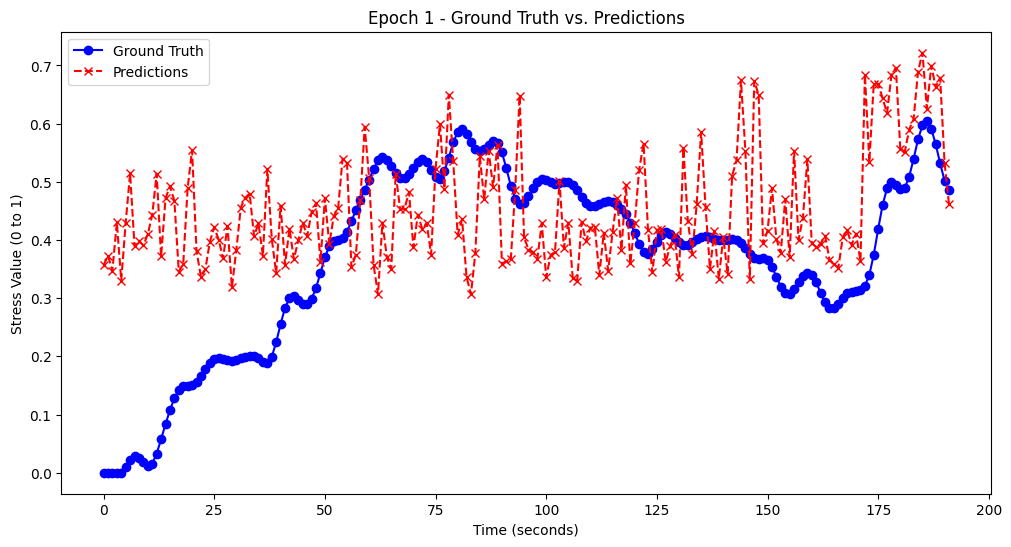

In [16]:
args = Args()
main(args)